<a href="https://colab.research.google.com/github/volodymyr-holovan/Analysis_Cafe_Sales_DTA2026/blob/main/Analysis/EDA_cafe_sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Analysis Cafe Sales

Cafe Sales - Dirty Data for Cleaning Training

**Overview**  
The Dirty Cafe Sales dataset contains 10,000 rows of synthetic data representing sales transactions in a cafe. This dataset is intentionally "dirty," with missing values, inconsistent data, and errors introduced to provide a realistic scenario for data cleaning and exploratory data analysis (EDA). It can be used to practice cleaning techniques, data wrangling, and feature engineering.

File Information  
File Name: dirty_cafe_sales.csv  
Number of Rows: 10,000  
Number of Columns: 8  

| Column Name | Description | Example Values |
| ----------- | ----------- | -------------- |
| `Transaction ID` | A unique identifier for each transaction. Always present and unique. | `TXN_1234567` |
| `Item` | The name of the item purchased. May contain missing or invalid values (e.g., "ERROR"). | `Coffee`, `Sandwich` |
| `Quantity` | The quantity of the item purchased. May contain missing or invalid values. | `1`, `3`, `UNKNOWN` |
| `Price Per Unit` | The price of a single unit of the item. May contain missing or invalid values. | `2.00`, `4.00` |
| `Total Spent` | The total amount spent on the transaction. Calculated as `Quantity * Price Per Unit`. | `8.00`, `12.00` |
| `Payment Method` | The method of payment used. May contain missing or invalid values (e.g., None, "UNKNOWN"). | `Cash`, `Credit Card` |
| `Location` | The location where the transaction occurred. May contain missing or invalid values. | `In-store`, `Takeaway`
| `Transaction Date` | The date of the transaction. May contain missing or incorrect values. | `2023-01-01` |

In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [83]:
# File path
# FILE_IN = "data/cafe_sales.csv"
FILE_IN = 'https://github.com/volodymyr-holovan/Analysis_Cafe_Sales_DTA2026/tree/main/Data/dirty_cafe_sales.csv'
# FILE_OUT = "data/cafe_sales_clean.csv"
FILE_OUT = "cafe_sales_clean.csv"

## Loading the dataset

In [84]:
url = 'https://raw.githubusercontent.com/KsiuTretyakova/Analysis_Cafe_Sales_DTA2026/refs/heads/main/data/dirty_cafe_sales.csv'

df_origin = pd.read_csv(url)
df_origin.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [85]:
df = df_origin.copy()

## Primary diagnosis

In [86]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [88]:
print("Data types (raw):\n")
df.dtypes

Data types (raw):



,0
Transaction ID,object
Item,object
Quantity,object
Price Per Unit,object
Total Spent,object
Payment Method,object
Location,object
Transaction Date,object


Problem:
- Numeric columns (Quantity, Price Per Unit, Total Spent)
- Date columns (Transaction Date)

In [89]:
print("Missing values:\n")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_report = pd.DataFrame({
    'count': missing,
    '%': missing_pct
})
missing_report[missing_report['count'] > 0]

Missing values:



,count,%
Item,333,3.3
Quantity,138,1.4
Price Per Unit,179,1.8
Total Spent,173,1.7
Payment Method,2579,25.8
Location,3265,32.6
Transaction Date,159,1.6


In [90]:
print("Unique values:\n")

print("--- Item ---\n")
# print(df['Item'].value_counts(dropna=False))
display(df['Item'].value_counts(dropna=False))

print("\n--- Payment Method ---\n")
display(df['Payment Method'].value_counts(dropna=False))

print("\n--- Location ---\n")
display(df['Location'].value_counts(dropna=False))

Unique values:

--- Item ---



,count
Item,
Juice,1171
Coffee,1165
Salad,1148
Cake,1139
Sandwich,1131
Smoothie,1096
Cookie,1092
Tea,1089
UNKNOWN,344



--- Payment Method ---



,count
Payment Method,
NaN,2579
Digital Wallet,2291
Credit Card,2273
Cash,2258
ERROR,306
UNKNOWN,293



--- Location ---



,count
Location,
NaN,3265
Takeaway,3022
In-store,3017
ERROR,358
UNKNOWN,338


In [91]:
print("Find lines with 'ERROR' or 'UNKNOWN'\n")
display(df.isin(['ERROR', 'UNKNOWN']).any())

mask_error = df.isin(['ERROR', 'UNKNOWN']).any(axis=1)
print(f"\nLines with 'ERROR' or 'UNKNOWN': {mask_error.sum()}")

Find lines with 'ERROR' or 'UNKNOWN'



,0
Transaction ID,False
Item,True
Quantity,True
Price Per Unit,True
Total Spent,True
Payment Method,True
Location,True
Transaction Date,True



Lines with 'ERROR' or 'UNKNOWN': 2845


## Data cleaning

In [92]:
print("Rename columns:\n")

df.columns = df.columns.str.strip()
# df.columns.str.lower().str.replace(" ", "_")
df = df.rename(columns={
    'Transaction ID': 'transaction_id',
    'Item': 'item',
    'Quantity': 'quantity',
    'Price Per Unit': 'price_per_unit',
    'Total Spent': 'total_spent',
    'Payment Method': 'payment_method',
    'Location': 'location',
    'Transaction Date': 'transaction_date'
})

print(list(df.columns))

Rename columns:

['transaction_id', 'item', 'quantity', 'price_per_unit', 'total_spent', 'payment_method', 'location', 'transaction_date']


In [93]:
# 'ERROR'/'UNKNOWN' -> NaN
df.replace(['ERROR', 'UNKNOWN', 'error', 'unknown', ''], np.nan, inplace=True)
df.head()

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [94]:
# Converting numeric columns
for col in ['quantity', 'price_per_unit', 'total_spent']:
  df[col] = pd.to_numeric(df[col], errors='coerce')

# Date conversion
df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')

In [95]:
print('Converting columns:\n')
df.dtypes

Converting columns:



,0
transaction_id,object
item,object
quantity,float64
price_per_unit,float64
total_spent,float64
payment_method,object
location,object
transaction_date,datetime64[ns]


In [96]:
# Extracting time signatures
df['year'] = df['transaction_date'].dt.year.astype('Int64')
df['month'] = df['transaction_date'].dt.month.astype('Int8')

# df['month_name'] = df['transaction_date'].dt.month_name()
df['month_name'] = df['transaction_date'].dt.strftime('%B')

df['weekday'] = df['transaction_date'].dt.day_name()
df['week'] = df['transaction_date'].dt.isocalendar().week.astype('Int8')


# display(df[['transaction_date', 'year', 'month', 'month_name', 'weekday', 'week']].dtypes)
df[['transaction_date', 'year', 'month', 'month_name', 'weekday', 'week']].head()

,transaction_date,year,month,month_name,weekday,week
0,2023-09-08,2023,9,September,Friday,36
1,2023-05-16,2023,5,May,Tuesday,20
2,2023-07-19,2023,7,July,Wednesday,29
3,2023-04-27,2023,4,April,Thursday,17
4,2023-06-11,2023,6,June,Sunday,23


In [97]:
# Restoring total_spent (quantity * price)

mask_recoverable = (
    df['total_spent'].isna() &
    df['quantity'].notna() &
    df['price_per_unit'].notna()
)

df.loc[mask_recoverable, 'total_spent'] = (
    df.loc[mask_recoverable, 'quantity'] *
    df.loc[mask_recoverable, 'price_per_unit']
)

print(f"Restoring total_spent: {mask_recoverable.sum()} string (quantity * price) ")

Restoring total_spent: 462 string (quantity * price) 


In [98]:
# dict of median prices
price_map = (
    df.dropna(subset=['item', 'price_per_unit'])
    .groupby('item')['price_per_unit']
    .median()
    .to_dict()
)

mask_price = df['price_per_unit'].isna() & df['item'].notna()

df.loc[mask_price, 'price_per_unit'] = df.loc[mask_price, 'item'].map(price_map)

print(f"Restoring price_per_unit: {mask_price.sum()} string (median per item) ")

Restoring price_per_unit: 479 string (median per item) 


In [99]:
# Restoring total_spent (new price - median item)

mask_recoverable2 = (
    df['total_spent'].isna() &
    df['quantity'].notna() &
    df['price_per_unit'].notna()
)

df.loc[mask_recoverable2, 'total_spent'] = (
    df.loc[mask_recoverable2, 'quantity'] *
    df.loc[mask_recoverable2, 'price_per_unit']
)

print(f"Restoring total_spent: {mask_recoverable2.sum()} string (new price - median item) ")

Restoring total_spent: 17 string (new price - median item) 


In [100]:
# fillna item -> mode
mode_item = df['item'].mode()[0]

# df['item'].fillna(mode_item, inplace=True)  # old version
df.fillna({'item': mode_item}, inplace=True)

In [101]:
# payment_method, location -> 'Unknown'
df.fillna(
    {
        'payment_method': 'Unknown',
        'location': 'Unknown'
    },
    inplace=True
)

In [102]:
# Delete transaction_date and quantity where NaT or NaN
before = len(df)

df.dropna(subset=['transaction_date', 'quantity'], inplace=True)

after = len(df)

print(f"Deleted {before - after} rows")

Deleted 914 rows


In [103]:
# Delete duplicates
df.duplicated().sum()  # 0
df.drop_duplicates(inplace=True)

In [104]:
(df.quantity <= 0).sum()  # 0
(df.price_per_unit <= 0).sum()  # 0
(df.total_spent <= 0).sum()  # 0

np.int64(0)

In [105]:
(df['quantity'].isna() & df['price_per_unit'].isna()).sum()

np.int64(0)

In [106]:
(df['quantity'].isna() | df['price_per_unit'].isna()).sum()

np.int64(48)

In [107]:
df.info()
# df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 9086 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    9086 non-null   object        
 1   item              9086 non-null   object        
 2   quantity          9086 non-null   float64       
 3   price_per_unit    9038 non-null   float64       
 4   total_spent       9083 non-null   float64       
 5   payment_method    9086 non-null   object        
 6   location          9086 non-null   object        
 7   transaction_date  9086 non-null   datetime64[ns]
 8   year              9086 non-null   Int64         
 9   month             9086 non-null   Int8          
 10  month_name        9086 non-null   object        
 11  weekday           9086 non-null   object        
 12  week              9086 non-null   Int8          
dtypes: Int64(1), Int8(2), datetime64[ns](1), float64(3), object(6)
memory usage: 896.2+

In [108]:
#Restoring price_per_unit (total_spent / quantity)
mask_recoverable3 = (
    df['price_per_unit'].isna() &
    df['total_spent'].notna() &
    df['quantity'].notna()
)

df.loc[mask_recoverable3, 'price_per_unit'] = df.loc[mask_recoverable3, 'total_spent'] / df.loc[mask_recoverable3, 'quantity']
# mask_recoverable.sum()

print(f"Restoring price_per_unit: {mask_recoverable3.sum()} (total_spent / quantity)")

Restoring price_per_unit: 45 (total_spent / quantity)


In [109]:
# Delete rows with NaN
df.dropna(subset=['total_spent'], inplace=True)

print(f"Delete rows with NaN (df['total_spent'].isna() & df['price_per_unit'].isna())")

Delete rows with NaN (df['total_spent'].isna() & df['price_per_unit'].isna())


In [110]:
df.isna().sum().sum()

np.int64(0)

In [111]:
# Check quantity * price_per_unit = total_spent
mask_total_spent = (df.quantity * df.price_per_unit != df.total_spent)
print(f"Uncorrect rows total_spent: {mask_total_spent.sum()}")

Uncorrect rows total_spent: 0


In [112]:
# Text fields are standartized (Title Case)
for col in ['item', 'payment_method',	'location']:
  df[col] = df[col].str.strip().str.title()

print("Text fields are standartized (Title Case)")

Text fields are standartized (Title Case)


## Cleaning results

In [113]:
# df_origin = name_your_origin_DataFrame
# df = name_your_clean_DataFrame

print("Cleaning results:")
print("=" * 20, "\n")

print(f"Rows before: {len(df_origin)}")
print(f"Rows after: {len(df)}")
print(f"Loss: {len(df_origin) - len(df)} ({(len(df_origin) - len(df)) / len(df_origin) * 100:.1f}%)")

print("\n--- Residual gaps ---")
remaining = df.isna().sum()
print(remaining[remaining > 0] if remaining.any() else "No gaps")

print("\n--- Data types after cleanup ---")
print(df.dtypes)
# display(df.dtypes)

print("\n--- Statistics ---")
print(df[['quantity', 'price_per_unit', 'total_spent']].describe().round(2))

Cleaning results:

Rows before: 10000
Rows after: 9083
Loss: 917 (9.2%)

--- Residual gaps ---
No gaps

--- Data types after cleanup ---
transaction_id              object
item                        object
quantity                   float64
price_per_unit             float64
total_spent                float64
payment_method              object
location                    object
transaction_date    datetime64[ns]
year                         Int64
month                         Int8
month_name                  object
weekday                     object
week                          Int8
dtype: object

--- Statistics ---
       quantity  price_per_unit  total_spent
count   9083.00         9083.00      9083.00
mean       3.03            2.95         8.93
std        1.42            1.28         6.00
min        1.00            1.00         1.00
25%        2.00            2.00         4.00
50%        3.00            3.00         8.00
75%        4.00            4.00        12.00
max        5.0

## Feature Engineering

In [114]:
# Season
season_map = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
}
df['season'] = df['month'].map(season_map)

# df[['month', 'season']].head()

In [115]:
# Is weekend
df['is_weekend'] = df['weekday'].isin(['Saturday', 'Sunday'])

In [116]:
# Check amount category
df['spend_tier'] = pd.cut(
    df['total_spent'],
    bins=[0, 5, 10, 20, 1000],
    labels=['Low', 'Medium', 'High', 'Premium']
)

In [117]:
print("New attributes: season, is_weekend, spend_tier")

New attributes: season, is_weekend, spend_tier


## Fast EDA (verificatoin graphs)

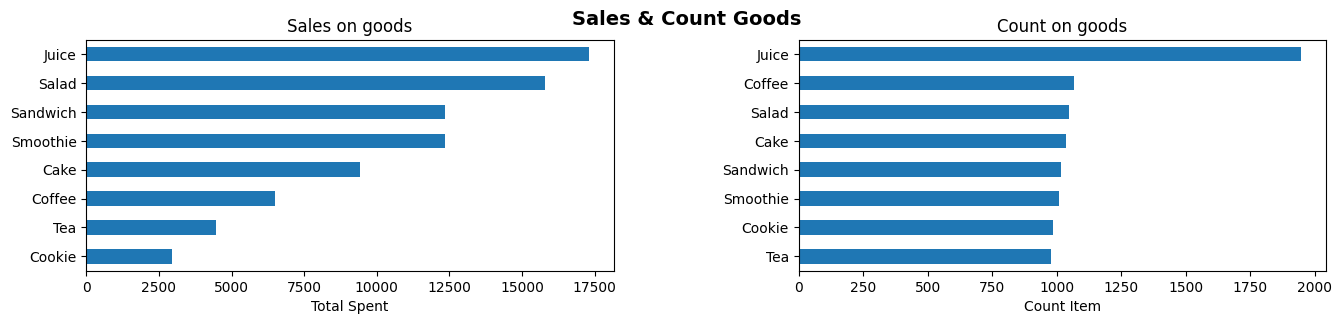

In [118]:
# Sales & Count goods
fig, axes = plt.subplots(1, 2, figsize=(16, 3))
fig.suptitle("Sales & Count Goods", fontsize=14, fontweight='bold')
plt.subplots_adjust(hspace=0.45, wspace=0.35)

# total_spent per item
ax = axes[0]  # axes[0, 0]
df.groupby('item')['total_spent'].sum().sort_values().plot(kind='barh', ax=ax)
ax.set_title("Sales on goods")
ax.set_xlabel("Total Spent")
ax.set_ylabel("")

# count per item
ax = axes[1]  # axes[0, 1]
df['item'].value_counts().sort_values().plot(kind='barh', ax=ax)
ax.set_title("Count on goods")
ax.set_xlabel("Count Item")
ax.set_ylabel("")

# plt.savefig('cafe_eda_1.png', dpi=150, bbox_inches='tight')

plt.show()

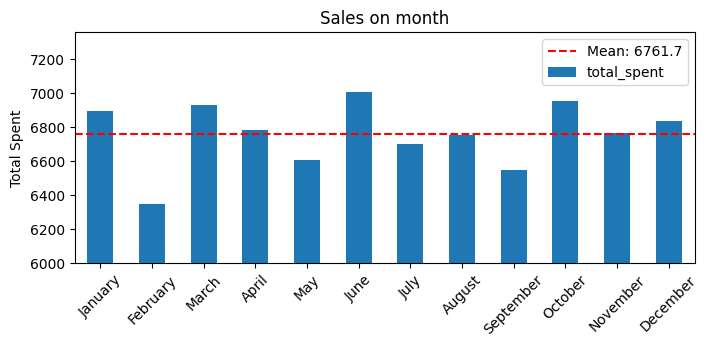

In [119]:
# Sales on month
fig = plt.figure(figsize=(8,3))
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
 ]

# print(df.groupby('month_name')['total_spent'].sum())
rev_month = df.groupby('month_name')['total_spent'].sum().reindex(
    [m for m in month_order if m in df['month_name'].unique()]
)

rev_month.plot(kind='bar', rot=45)


mean_value = rev_month.mean()
# std_value = rev_month.std()
# std_pct = (std_value / mean_value) * 100

plt.axhline(y=mean_value, color='red', linestyle='--', linewidth=1.5, label=f"Mean: {mean_value:.1f}")

plt.ylim(bottom=6000)


plt.title("Sales on month")
plt.xlabel("")
plt.ylabel("Total Spent")
plt.legend(loc='upper right')
# plt.legend(bbox_to_anchor=(1.26, 1), loc='upper right')

# plt.text(1.02, 0.6, f"std: {std_pct:.2f}%", transform=plt.gca().transAxes,
#          bbox=dict(boxstyle='round, pad=0.3', facecolor='white', alpha=0.7)
#          )

# plt.savefig('cafe_eda_2.png', dpi=150, bbox_inches='tight')
plt.show()

In [120]:
# Save figure
plt.savefig('cafe_eda.png', dpi=150, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

## Saving a clean CSV for Tableau

In [121]:
# df['transaction_date'] = df_origin['Transaction Date'].copy()
# df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')

In [122]:
# For Tableau better date format: YYYY-MM-DD
df['transaction_date'] = df['transaction_date'].dt.strftime('%Y-%m-%d')

# For Tableau: bool -> str
df['is_weekend'] = df['is_weekend'].map({
    True: 'Yes',
    False: 'No'
})

df.to_csv(FILE_OUT, index=False, encoding='utf-8-sig')

print(f"Saved: {FILE_OUT}")  # work in colab ('data/file_name.csv')
print(f"Rows: {len(df)} | Columns: {df.shape[1]}")
print(f"Columns: {list(df.columns)}")

Saved: cafe_sales_clean.csv
Rows: 9083 | Columns: 16
Columns: ['transaction_id', 'item', 'quantity', 'price_per_unit', 'total_spent', 'payment_method', 'location', 'transaction_date', 'year', 'month', 'month_name', 'weekday', 'week', 'season', 'is_weekend', 'spend_tier']
